<a href="https://colab.research.google.com/github/chrisampiah/Content/blob/main/myelin_classifier_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Myelin Maturation Classifier: Delayed vs Normal
**Dataset:** Large dataset of infancy and early childhood brain MRIs (T1w and T2w)  

**Task:** Binary classification — `delayed` vs `normal` myelination from T1w + T2w NIfTI volumes

> ⚠️ **Runtime:** Set to `T4 GPU` via Runtime → Change runtime type → GPU

## 1. Install dependencies

In [14]:
!pip install -q nibabel nilearn zenodo-get scikit-learn monai einops

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 106.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.2/254.2 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.3 MB/s eta 0:00:00


## 2. Download the dataset from Zenodo
This will download ~833 subject folders + `meta.csv`. Takes ~10-20 min on Colab.

In [15]:
import os

DATA_DIR = "/content/myelin_dataset"
os.makedirs(DATA_DIR, exist_ok=True)

# Download from Zenodo record 8055666
!zenodo_get 10.5281/zenodo.8055666 -o {DATA_DIR}

# List top-level contents
!ls {DATA_DIR} | head -20

INFO: Output directory: /content/myelin_dataset
INFO: Title: Large dataset of infancy and early childhood brain MRIs (T1w and T2w)
INFO: Total size: 12.1 GB
INFO: Number of files: 1
SUCCESS: All specified files have been processed.
zenodo_upload_v2.zip


In [16]:
import zipfile

for file in os.listdir(DATA_DIR):
    if file.endswith(".zip"):
        with zipfile.ZipFile(os.path.join(DATA_DIR, file), 'r') as zip_ref:
            zip_ref.extractall(DATA_DIR)

## 3. Inspect the metadata

In [17]:
import pandas as pd
import glob
import os

# Check if the zip file exists and unzip if it hasn't been already
zip_file_path = os.path.join(DATA_DIR, "zenodo_upload_v2.zip")
if os.path.exists(zip_file_path) and not glob.glob(f"{DATA_DIR}/**/*.csv", recursive=True):
    print(f"Unzipping {zip_file_path}...")
    !unzip {zip_file_path} -d {DATA_DIR}
    # It's good practice to remove the zip file after extraction if not needed
    # os.remove(zip_file_path)

meta_path = glob.glob(f"{DATA_DIR}/**/*.csv", recursive=True)[0]

# Original code that caused the error (will be re-evaluated after inspection)
df = pd.read_csv(meta_path, delimiter=';')
print(df.shape)
print(df.columns.tolist())
df.head()

(833, 7)
['image_id', 'myelinisation', 'age', 'age_corrected', 'doctor_predicted_age', 'diagnosis', 'group']


,image_id,myelinisation,age,age_corrected,doctor_predicted_age,diagnosis,group
0,s0001,normal,22,22,22,normal,train
1,s0002,normal,29,29,29,normal,train
2,s0003,normal,4,4,4,normal,train
3,s0004,normal,0,0,0,normal,train
4,s0005,normal,0,0,0,normal,train


In [18]:
# Label distribution
print(df['myelinisation'].value_counts())

myelinisation
normal     829
delayed      4
Name: count, dtype: int64


## 4. Build file paths and filter to delayed / normal only

In [19]:
import os, glob
import nibabel as nib
import numpy as np

# Keep only delayed and normal
df_bin = df[df['myelinisation'].isin(['delayed', 'normal'])].copy()
df_bin['label'] = (df_bin['myelinisation'] == 'delayed').astype(int)  # 1=delayed, 0=normal

print(f"Samples after filtering: {len(df_bin)}")
print(df_bin['myelinisation'].value_counts())

# ------------------------------------------------------------------
# Build T1w and T2w file paths.
# The dataset folder structure is: /content/myelin_dataset/sXXX/tY.nii.gz
# ------------------------------------------------------------------
def find_nifti(subject_id, modality, data_dir):
    """Find a NIfTI file for a given subject and modality (T1w or T2w)."""
    # Map the abstract modality name (T1w, T2w) to the actual filename prefix (t1, t2)
    filename_prefix = ''
    if modality == 'T1w':
        filename_prefix = 't1'
    elif modality == 'T2w':
        filename_prefix = 't2'
    else:
        return None # Should not happen with expected inputs

    # Construct the base filename, e.g., 't1.nii.gz'
    nifti_filename = f"{filename_prefix}.nii.gz"

    # Define patterns to search for. The most direct one first.
    # The `subject_id` should match the directory name, e.g., 's0001'.
    patterns = [
        # Pattern 1: Direct path: DATA_DIR/subject_id/tX.nii.gz
        os.path.join(data_dir, subject_id, nifti_filename),
        # Pattern 2: Subject ID folder might have extra characters, e.g., s0001_desc-preproc/tX.nii.gz
        os.path.join(data_dir, f"*{subject_id}*", nifti_filename),
        # Pattern 3: Files might be nested deeper, e.g., DATA_DIR/subject_id/ses-01/anat/tX.nii.gz
        os.path.join(data_dir, subject_id, '**', nifti_filename),
        # Pattern 4: Combination of 2 and 3
        os.path.join(data_dir, f"*{subject_id}*", '**', nifti_filename),
    ]

    for p in patterns:
        hits = glob.glob(p, recursive=True)
        if hits:
            return hits[0] # Return the first match
    return None # No file found


# Detect the subject-id column (common names in this dataset)
id_col = next(c for c in ['subject', 'subject_id', 'sub', 'id', 'SubjectID', 'image_id'] if c in df_bin.columns)
print(f"Using ID column: {id_col}")

t1_paths, t2_paths, valid_idx = [], [], []
for i, row in df_bin.iterrows():
    sid = str(row[id_col])
    t1 = find_nifti(sid, 'T1w', DATA_DIR)
    t2 = find_nifti(sid, 'T2w', DATA_DIR)
    if t1 and t2:
        t1_paths.append(t1)
        t2_paths.append(t2)
        valid_idx.append(i)

df_valid = df_bin.loc[valid_idx].copy()
df_valid['t1_path'] = t1_paths
df_valid['t2_path'] = t2_paths
print(f"Subjects with both T1w + T2w found: {len(df_valid)}")

Samples after filtering: 833
myelinisation
normal     829
delayed      4
Name: count, dtype: int64
Using ID column: image_id
Subjects with both T1w + T2w found: 833


## 5. MONAI transforms — resize + normalise 3-D volumes

In [20]:
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd,
    Spacingd, Orientationd, ScaleIntensityRangePercentilesd,
    Resized, ConcatItemsd, ToTensord
)

TARGET_SHAPE = (64, 64, 64)   # Reduce if OOM; increase for better accuracy

train_transforms = Compose([
    LoadImaged(keys=['t1', 't2']),
    EnsureChannelFirstd(keys=['t1', 't2']),
    Orientationd(keys=['t1', 't2'], axcodes='RAS'),
    Spacingd(keys=['t1', 't2'], pixdim=(2.0, 2.0, 2.0), mode='bilinear'),
    ScaleIntensityRangePercentilesd(keys=['t1', 't2'], lower=1, upper=99,
                                     b_min=0.0, b_max=1.0, clip=True),
    Resized(keys=['t1', 't2'], spatial_size=TARGET_SHAPE),
    ConcatItemsd(keys=['t1', 't2'], name='image', dim=0),  # → (2, D, H, W)
    ToTensord(keys=['image'])
])

val_transforms = train_transforms  # same pipeline; add augmentations to train only if desired

/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


## 6. Dataset and DataLoaders

In [21]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

class MyelinDataset(Dataset):
    def __init__(self, dataframe, transforms):
        self.df = dataframe.reset_index(drop=True)
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        data_dict = {'t1': row['t1_path'], 't2': row['t2_path']}
        data_dict = self.transforms(data_dict)
        image = data_dict['image']           # (2, D, H, W)
        label = torch.tensor(row['label'], dtype=torch.long)
        return image, label

# 50/25/25 stratified split
train_df, val_test_df = train_test_split(df_valid, test_size=0.50, stratify=df_valid['label'], random_state=42)
val_df, test_df   = train_test_split(val_test_df, test_size=0.50, stratify=val_test_df['label'], random_state=42)

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")

# Check class distributions
print("\nTrain label counts:")
print(train_df['label'].value_counts())
print("\nVal label counts:")
print(val_df['label'].value_counts())
print("\nTest label counts:")
print(test_df['label'].value_counts())

BATCH = 4
train_ds = MyelinDataset(train_df, train_transforms)
val_ds   = MyelinDataset(val_df,   val_transforms)
test_ds  = MyelinDataset(test_df,  val_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

Train: 416  Val: 208  Test: 209

Train label counts:
label
0    414
1      2
Name: count, dtype: int64

Val label counts:
label
0    207
1      1
Name: count, dtype: int64

Test label counts:
label
0    208
1      1
Name: count, dtype: int64


## 7. Model — 3D ResNet-18 (MONAI)

In [22]:
from monai.networks.nets import resnet18

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = resnet18(
    pretrained=False,
    spatial_dims=3,
    n_input_channels=2,   # T1w + T2w concatenated
    num_classes=2
).to(device)

print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Using device: cuda
Parameters: 33,183,874


## 8. Loss, optimiser, scheduler

In [23]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

# Class weights to handle imbalance (delayed is typically rarer)
counts = df_valid['label'].value_counts().sort_index().values
weights = torch.tensor(counts.max() / counts, dtype=torch.float32).to(device)
print(f"Class weights: {weights}")

criterion = torch.nn.CrossEntropyLoss(weight=weights)
optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-6)

Class weights: tensor([  1.0000, 207.2500], device='cuda:0')


## 9. Training loop

In [24]:
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
import torch.nn.functional as F

EPOCHS = 30
SAVE_PATH = "/content/best_myelin_model.pth"

best_val_auc = 0.0
history = {'train_loss': [], 'val_loss': [], 'val_bacc': [], 'val_auc': []}

def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss, all_labels, all_probs = 0, [], []
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss   = criterion(logits, labels)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(labels)
            probs = F.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    preds    = (np.array(all_probs) >= 0.5).astype(int)
    bacc     = balanced_accuracy_score(all_labels, preds)
    auc      = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.0
    return avg_loss, bacc, auc

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_bacc, tr_auc = run_epoch(train_loader, training=True)
    vl_loss, vl_bacc, vl_auc = run_epoch(val_loader,   training=False)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['val_bacc'].append(vl_bacc)
    history['val_auc'].append(vl_auc)

    if vl_auc > best_val_auc:
        best_val_auc = vl_auc
        torch.save(model.state_dict(), SAVE_PATH)
        flag = " ✓ saved"
    else:
        flag = ""

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train loss {tr_loss:.4f} | "
          f"Val loss {vl_loss:.4f}  Bal-Acc {vl_bacc:.3f}  AUC {vl_auc:.3f}{flag}")

Epoch 01/30 | Train loss 0.1291 | Val loss 0.1092  Bal-Acc 0.500  AUC 0.758 ✓ saved
Epoch 02/30 | Train loss 0.1060 | Val loss 0.1080  Bal-Acc 0.500  AUC 0.087
Epoch 03/30 | Train loss 0.1089 | Val loss 0.1032  Bal-Acc 0.500  AUC 0.541
Epoch 04/30 | Train loss 0.1008 | Val loss 0.1032  Bal-Acc 0.500  AUC 0.565
Epoch 05/30 | Train loss 0.1062 | Val loss 0.1055  Bal-Acc 0.500  AUC 0.213
Epoch 06/30 | Train loss 0.1054 | Val loss 0.0964  Bal-Acc 0.500  AUC 0.768 ✓ saved
Epoch 07/30 | Train loss 0.0912 | Val loss 0.1403  Bal-Acc 0.500  AUC 0.135
Epoch 08/30 | Train loss 0.0436 | Val loss 0.1124  Bal-Acc 0.500  AUC 0.478
Epoch 09/30 | Train loss 0.0954 | Val loss 0.0955  Bal-Acc 0.500  AUC 0.507
Epoch 10/30 | Train loss 0.0972 | Val loss 0.1100  Bal-Acc 0.500  AUC 0.169
Epoch 11/30 | Train loss 0.0852 | Val loss 0.1086  Bal-Acc 0.500  AUC 0.430
Epoch 12/30 | Train loss 0.0412 | Val loss 0.1318  Bal-Acc 0.495  AUC 0.502
Epoch 13/30 | Train loss 0.0499 | Val loss 0.1186  Bal-Acc 0.500  AUC 0.

## 10. Training curves

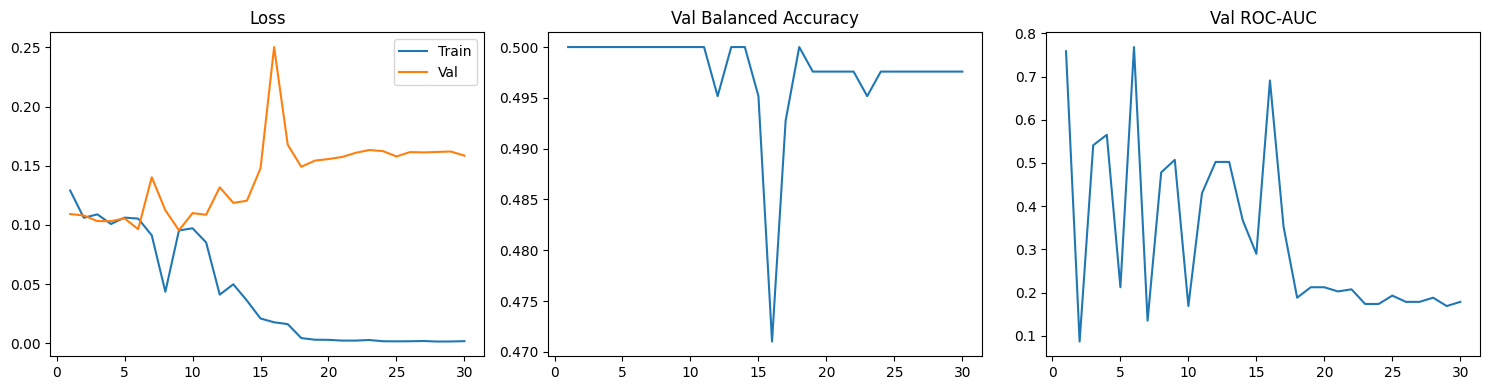

In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs, history['train_loss'], label='Train')
axes[0].plot(epochs, history['val_loss'],   label='Val')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(epochs, history['val_bacc'])
axes[1].set_title('Val Balanced Accuracy')

axes[2].plot(epochs, history['val_auc'])
axes[2].set_title('Val ROC-AUC')

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=120)
plt.show()

## 11. Evaluate on hold-out test set

=== Test Set Results ===
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00       208
     delayed       0.00      0.00      0.00         1

    accuracy                           1.00       209
   macro avg       0.50      0.50      0.50       209
weighted avg       0.99      1.00      0.99       209

ROC-AUC: 0.0048


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


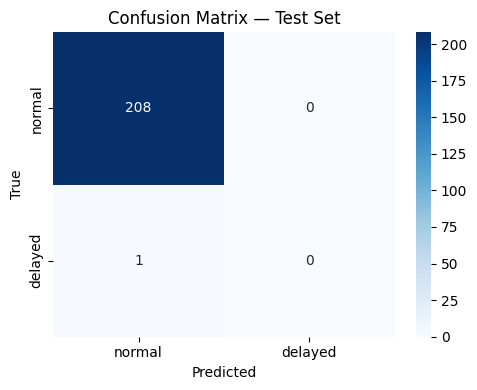

In [44]:
import torch
import torch.nn.functional as F
from monai.networks.nets import resnet18
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = resnet18(
    pretrained=False,
    spatial_dims=3,
    n_input_channels=2,   # T1w + T2w concatenated
    num_classes=2
).to(device)

model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
model.eval()

all_labels, all_preds, all_probs = [], [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        logits = model(images)
        probs  = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds  = (probs >= 0.5).astype(int)
        all_labels.extend(labels.numpy())
        all_preds.extend(preds)
        all_probs.extend(probs)

print("=== Test Set Results ===")
print(classification_report(all_labels, all_preds, target_names=['normal', 'delayed']))
print(f"ROC-AUC: {roc_auc_score(all_labels, all_probs):.4f}")

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['normal', 'delayed'],
            yticklabels=['normal', 'delayed'])
plt.ylabel('True'); plt.xlabel('Predicted')
plt.title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=120)
plt.show()

## 12. ROC curve

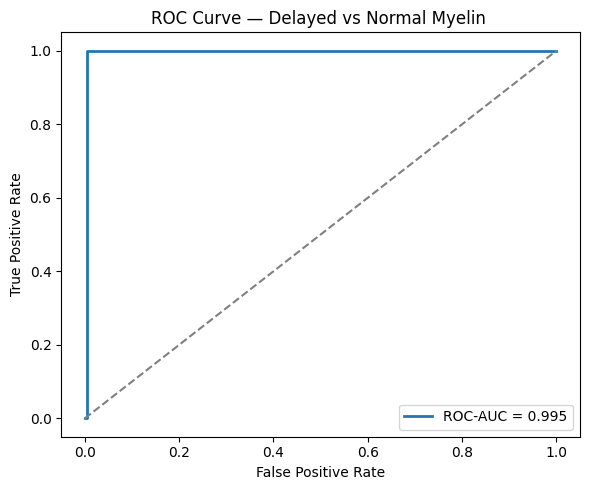

In [43]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(all_labels, new_pred)
auc_score   = roc_auc_score(all_labels, new_pred)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, label=f'ROC-AUC = {auc_score:.3f}')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Delayed vs Normal Myelin ')
plt.legend()
plt.tight_layout()
plt.savefig('/content/roc_curve_new_pred.png', dpi=120)
plt.show()

## 13. (Optional) GradCAM saliency on one test volume

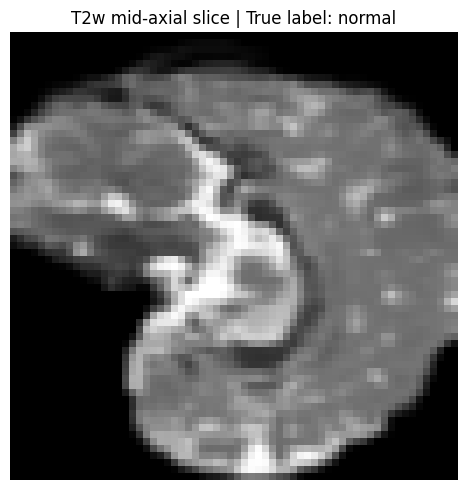

In [28]:
# Install grad-cam for 3D support
!pip install -q grad-cam

# Visualise a single mid-axial slice from the first test subject
sample_image, sample_label = test_ds[0]
sample_image = sample_image.unsqueeze(0).to(device)   # (1, 2, D, H, W)

# Show T2w mid-slice
t2_vol = sample_image[0, 1].cpu().numpy()             # (D, H, W)
mid    = t2_vol.shape[0] // 2

plt.figure(figsize=(5, 5))
plt.imshow(t2_vol[mid], cmap='gray')
plt.title(f"T2w mid-axial slice | True label: {'delayed' if sample_label==1 else 'normal'}")
plt.axis('off')
plt.tight_layout()
plt.savefig('/content/sample_t2w_slice.png', dpi=120)
plt.show()

---
## Notes
- **Dataset download** takes ~10–20 min; the ~833 NIfTI pairs are several GB total.
- **`TARGET_SHAPE`** is set to `(64,64,64)` to fit in GPU RAM. Raise to `(96,96,96)` for better accuracy at the cost of memory.
- **Class imbalance**: weighted cross-entropy is applied automatically based on label counts.
- **Accelerated class** is excluded by the binary filter in cell 4 — remove the filter and change `num_classes=3` to include it.
- **Cite the dataset**: Akinci D'Antonoli et al., Radiology: AI, https://pubs.rsna.org/doi/10.1148/ryai.220292